## aai-511-final-project-group1


In [ ]:
# Import required libraries


## 1. Data Collection:

Data is collected and provided to you.



In [4]:
# Install kagglehub for dataset download
%pip install kagglehub -q

import kagglehub
import os
from pathlib import Path

print("="*80)
print("DOWNLOADING MIDI CLASSIC MUSIC DATASET FROM KAGGLE")
print("="*80)

# Download latest version of the dataset
print("\nDownloading dataset from Kaggle...")
path = kagglehub.dataset_download("blanderbuss/midi-classic-music")

print(f"\n✓ Dataset downloaded successfully!")
print(f"Path to dataset files: {path}")

# Set the dataset path for later use
dataset_path = path

# List all files and directories in the dataset path
print(f"\nExploring dataset structure...")
print("="*80)

try:
    # List items in the dataset directory
    items = os.listdir(dataset_path)
    print(f"\nFound {len(items)} items in the dataset directory:\n")

    for item in sorted(items)[:15]:
        item_path = os.path.join(dataset_path, item)
        item_type = "DIR" if os.path.isdir(item_path) else "FILE"
        print(f"  [{item_type}] {item}")

    if len(items) > 15:
        print(f"\n... and {len(items) - 15} more items")

except Exception as e:
    print(f"Error accessing dataset: {e}")

print("\n" + "="*80)


DOWNLOADING MIDI CLASSIC MUSIC DATASET FROM KAGGLE



100%|██████████| 68.2M/68.2M [00:00<00:00, 82.2MB/s]

Extracting files...



✓ Dataset downloaded successfully!
Path to dataset files: /root/.cache/kagglehub/datasets/blanderbuss/midi-classic-music/versions/1

Exploring dataset structure...

Found 25 items in the dataset directory:

  [DIR] Albe╠üniz
  [DIR] Alkan
  [DIR] Ambroise
  [DIR] Arensky
  [DIR] Arndt
  [FILE] Rothchild Symphony Rmw12 2mov.mid
  [FILE] Rothchlid Symphony Rmw12 3mov.mid
  [FILE] Sibelius Kuolema Vals op44.mid
  [FILE] Tchaicovsky Waltz of the Flowers.MID
  [FILE] Tchaikovsky Lake Of The Swans Act 1 1mov.mid
  [FILE] Tchaikovsky Lake Of The Swans Act 1 2mov.mid
  [FILE] Tchaikovsky Lake Of The Swans Act 1 3mov.mid
  [FILE] Tchaikovsky Lake Of The Swans Act 1 4mov.mid
  [FILE] Tchaikovsky Lake Of The Swans Act 1 5mov.mid
  [FILE] Tchaikovsky Lake Of The Swans Act 1 6mov.mid

... and 10 more items



In [5]:
# Explore midiclassics.zip file - 4 Composers
import os
import zipfile
import shutil
from collections import defaultdict

print("="*80)
print("EXPLORING MIDICLASSICS.ZIP FILE")
print("="*80)

# Define the 4 composers we want to find
target_composers = ['bach', 'beethoven', 'chopin', 'mozart']

print(f"\nTarget composers: {', '.join([c.title() for c in target_composers])}")

# Look for midiclassics.zip in the dataset path
zip_file_path = os.path.join(dataset_path, 'midiclassics.zip')

print(f"\nLooking for zip file at: {zip_file_path}")

if not os.path.exists(zip_file_path):
    print(f"\n✗ midiclassics.zip not found at {zip_file_path}")
    print("\nSearching for zip files in dataset directory...")

    # Search for any zip files
    zip_files = [f for f in os.listdir(dataset_path) if f.endswith('.zip')]

    if zip_files:
        print(f"\nFound {len(zip_files)} zip file(s):")
        for zf in zip_files:
            print(f"  • {zf}")

        # Use the first zip file found
        zip_file_path = os.path.join(dataset_path, zip_files[0])
        print(f"\nUsing: {zip_files[0]}")
    else:
        print("\n✗ No zip files found in dataset directory")
        raise FileNotFoundError("midiclassics.zip not found")

print("\n" + "="*80)
print("ANALYZING ZIP FILE CONTENTS")
print("="*80)

# Explore the zip file contents
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    # Get all file names in the zip
    all_files = zip_ref.namelist()

    print(f"\nTotal files in zip: {len(all_files)}")

    # Organize files by composer
    composer_files = defaultdict(list)
    all_composers_found = set()

    for file_path in all_files:
        # Skip directories
        if file_path.endswith('/'):
            continue

        # Check if it's a MIDI file
        if file_path.lower().endswith(('.mid', '.midi')):
            # Extract composer name from path
            path_parts = file_path.split('/')

            # Try to find composer name in the path
            for part in path_parts:
                part_lower = part.lower()
                all_composers_found.add(part)

                # Check if this part matches any target composer
                for composer in target_composers:
                    if composer in part_lower:
                        composer_files[composer].append(file_path)
                        break

    print("\n" + "="*80)
    print("ALL COMPOSERS/FOLDERS FOUND IN ZIP")
    print("="*80)

    # Show all unique folder names
    folders = set()
    for file_path in all_files:
        parts = file_path.split('/')
        if len(parts) > 1:
            folders.add(parts[0])

    for folder in sorted(folders):
        marker = "✓" if any(tc in folder.lower() for tc in target_composers) else "✗"
        print(f"  [{marker}] {folder}")

    # Display statistics for target composers
    print("\n" + "="*80)
    print("MIDI FILES FOR TARGET COMPOSERS")
    print("="*80)

    composer_stats = {}
    for composer in target_composers:
        if composer in composer_files:
            midi_count = len(composer_files[composer])
            composer_stats[composer] = {
                'files': composer_files[composer],
                'midi_count': midi_count
            }

            print(f"\n{composer.title()}:")
            print(f"  MIDI files: {midi_count}")
            print(f"  Sample files:")
            for file_path in composer_files[composer][:3]:
                print(f"    • {file_path}")
            if midi_count > 3:
                print(f"    ... and {midi_count - 3} more")
        else:
            print(f"\n{composer.title()}: NOT FOUND")

    # Extract the zip file to a writable directory
    # (Kaggle/Databricks dataset mounts are often read-only)
    extract_path = os.path.join(os.getcwd(), 'extracted_midi')

    print("\n" + "="*80)
    print("EXTRACTING ZIP FILE")
    print("="*80)

    print(f"\nExtracting to: {extract_path}")

    # Create extraction directory if it doesn't exist
    os.makedirs(extract_path, exist_ok=True)

    # Extract all files
    zip_ref.extractall(extract_path)

    print("✓ Extraction complete!")

    # Update dataset_path to point to extracted location
    dataset_path = extract_path

# Summary
total_files = sum([stats['midi_count'] for stats in composer_stats.values()])
print("\n" + "="*80)
print("SUMMARY")
print("="*80)
print(f"\nTotal MIDI files (4 composers): {total_files}")
print(f"Composers found: {len(composer_stats)}")
print(f"Extracted to: {dataset_path}")

print("\n" + "="*80)
print("ZIP FILE EXPLORATION COMPLETE!")
print("="*80)

EXPLORING MIDICLASSICS.ZIP FILE

Target composers: Bach, Beethoven, Chopin, Mozart

Looking for zip file at: /root/.cache/kagglehub/datasets/blanderbuss/midi-classic-music/versions/1/midiclassics.zip

ANALYZING ZIP FILE CONTENTS

Total files in zip: 4867

ALL COMPOSERS/FOLDERS FOUND IN ZIP
  [✗] Albéniz
  [✗] Alkan
  [✗] Ambroise
  [✗] Arensky
  [✗] Arndt
  [✗] Bacewitz
  [✓] Bach
  [✗] Barber
  [✗] Bartelet
  [✗] Bartok
  [✗] Becker
  [✓] Beethoven
  [✗] Bellini
  [✗] Berlin
  [✗] Bernstein
  [✗] Borodin
  [✗] Botsford
  [✗] Brahms
  [✗] Burgmuller
  [✗] Busoni
  [✗] Busser
  [✗] Buxehude
  [✗] Chabrier
  [✗] Chaminade
  [✗] Chasins
  [✓] Chopin
  [✗] Clarke
  [✗] Clementi
  [✗] Coates
  [✗] Coleridge-Taylor
  [✗] Cons
  [✗] Copland
  [✗] Couperin
  [✗] Cramer
  [✗] Czerny
  [✗] Czibulka
  [✗] Debussy
  [✗] Durand, E
  [✗] Durand, MA
  [✗] Dussek
  [✗] Dvorak
  [✗] Faure
  [✗] Field
  [✗] Finck
  [✗] Flotow
  [✗] Franck
  [✗] Frescobaldi
  [✗] Friedman
  [✗] Fucick
  [✗] Ganne
  [✗] 

## 2.1 Exploratory Data Analysis (EDA)

EDA examines the statistical properties and patterns of MIDI files across 9 composers (Bach, Bartok, Byrd, Chopin, Handel, Hummel, Mendelssohn, Mozart, and Schumann), analyzing duration, tempo, complexity, and pitch characteristics to identify distinguishing features for classification. This analysis reveals data quality issues, informs feature selection for the deep learning model, and guides preprocessing decisions.



In [6]:
# Install required library for MIDI processing
%pip install pretty_midi

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 57.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 6.0 MB/s eta 0:00:00
  Created wheel for pretty_midi: filename=pretty_midi-0.2.11-py3-none-any.whl size=5595886 sha256=af8fa30fed58e320bdca88253fefb10f4b098c2cf9a402d3a09167f57866be04
  Stored in directory: /root/.cache/pip/wheels/f4/ad/93/a7042fe12668827574927ade9deec7f29aad2a1001b1501882
Successfully built pretty_midi


In [7]:
# Exploratory Data Analysis on 4 Composers
import pretty_midi
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

print("="*80)
print("EXPLORATORY DATA ANALYSIS (EDA) - 4 COMPOSERS")
print("="*80)

# Define the 4 composers
composers = ['bach', 'beethoven', 'chopin', 'mozart']

print(f"\nAnalyzing: {', '.join([c.title() for c in composers])}")
print("\n" + "="*80)

# Initialize data structures for EDA
composer_stats = []

# Analyze files from each composer
for composer in composers:
    # Find the matching folder (case-insensitive)
    all_folders = [f for f in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, f))]
    matching_folders = [f for f in all_folders if f.lower() == composer.lower()]

    if not matching_folders:
        print(f"✗ {composer.title()}: Folder not found")
        continue

    composer_folder = matching_folders[0]
    composer_path = os.path.join(dataset_path, composer_folder)

    try:
        # Get all MIDI files for this composer
        midi_files = [f for f in os.listdir(composer_path)
                     if f.endswith('.mid') or f.endswith('.midi')]

        print(f"\n{composer.title()}: Analyzing {len(midi_files)} MIDI files...")

        # Analyze files from this composer (sample first 10 for quick EDA)
        files_processed = 0
        for midi_file in midi_files[:10]:
            try:
                midi_file_path = os.path.join(composer_path, midi_file)

                # Load MIDI file
                midi_data = pretty_midi.PrettyMIDI(midi_file_path)

                # Extract features
                stats = {
                    'composer': composer,
                    'file_name': midi_file,
                    'duration_sec': midi_data.get_end_time(),
                    'tempo_estimate': midi_data.estimate_tempo(),
                    'num_instruments': len(midi_data.instruments)
                }

                # Count total notes across all instruments
                total_notes = sum([len(instrument.notes) for instrument in midi_data.instruments])
                stats['total_notes'] = total_notes

                # Get pitch statistics
                if midi_data.instruments:
                    pitches = [note.pitch for instrument in midi_data.instruments
                              for note in instrument.notes if not instrument.is_drum]
                    if pitches:
                        stats['pitch_mean'] = np.mean(pitches)
                        stats['pitch_std'] = np.std(pitches)
                        stats['pitch_range'] = max(pitches) - min(pitches)
                        stats['pitch_min'] = min(pitches)
                        stats['pitch_max'] = max(pitches)
                    else:
                        stats['pitch_mean'] = 0
                        stats['pitch_std'] = 0
                        stats['pitch_range'] = 0
                        stats['pitch_min'] = 0
                        stats['pitch_max'] = 0
                else:
                    stats['pitch_mean'] = 0
                    stats['pitch_std'] = 0
                    stats['pitch_range'] = 0
                    stats['pitch_min'] = 0
                    stats['pitch_max'] = 0

                composer_stats.append(stats)
                files_processed += 1

            except Exception as e:
                print(f"  ⚠ Error processing {midi_file}: {str(e)[:50]}...")
                continue

        print(f"  ✓ Successfully processed {files_processed} files")

    except Exception as e:
        print(f"  ✗ Error accessing {composer}: {e}")

print("\n" + "="*80)
print(f"TOTAL FILES ANALYZED: {len(composer_stats)}")
print("="*80)

# Create DataFrame and display summary statistics
if len(composer_stats) > 0:
    df_stats = pd.DataFrame(composer_stats)

    print("\nSummary Statistics by Composer:")
    print("-" * 80)

    summary = df_stats.groupby('composer').agg({
        'duration_sec': ['mean', 'std', 'min', 'max'],
        'tempo_estimate': ['mean', 'std', 'min', 'max'],
        'total_notes': ['mean', 'std', 'min', 'max'],
        'num_instruments': ['mean', 'max'],
        'pitch_mean': ['mean', 'std'],
        'pitch_range': ['mean', 'max']
    }).round(2)

    display(summary)

    print("\nOverall Dataset Statistics:")
    print(f"  Average duration: {df_stats['duration_sec'].mean():.2f} seconds")
    print(f"  Average tempo: {df_stats['tempo_estimate'].mean():.2f} BPM")
    print(f"  Average notes per file: {df_stats['total_notes'].mean():.0f}")
    print(f"  Average pitch: {df_stats['pitch_mean'].mean():.2f} (MIDI note number)")
    print(f"  Average instruments: {df_stats['num_instruments'].mean():.2f}")

    print("\n" + "="*80)
else:
    print("\n⚠ WARNING: No files were successfully processed. Check file paths and MIDI file format.")
    print("="*80)

EXPLORATORY DATA ANALYSIS (EDA) - 4 COMPOSERS

Analyzing: Bach, Beethoven, Chopin, Mozart


Bach: Analyzing 122 MIDI files...
  ✓ Successfully processed 10 files

Beethoven: Analyzing 133 MIDI files...
  ✓ Successfully processed 10 files

Chopin: Analyzing 136 MIDI files...
  ✓ Successfully processed 10 files

Mozart: Analyzing 90 MIDI files...
  ✓ Successfully processed 10 files

TOTAL FILES ANALYZED: 40

Summary Statistics by Composer:
--------------------------------------------------------------------------------


duration_sec                        tempo_estimate                 \
                  mean     std    min     max           mean    std     min   
composer                                                                      
bach            286.33  258.78  55.47  908.38         206.56  47.99  124.90   
beethoven       363.08  239.21  41.52  786.91         212.04  23.59  188.63   
chopin          227.39  120.30  51.08  392.32         195.01  26.67  153.65   
mozart          323.82  218.06  59.26  809.76         196.95  30.28  141.88   

                  total_notes                      num_instruments      \
              max        mean      std  min    max            mean max   
composer                                                                 
bach       291.74      2103.1  1905.34  556   6604             4.5  12   
beethoven  274.13      5335.0  4530.59  534  14150             6.0  18   
chopin     243.61      1954.4  1409.12  527   5615             2.2   4   
mozart     230.69      4235.8  3447.20  378  10671             5.7  10   

          pitch_mean       pitch_range      
                mean   std        mean max  
composer                                    
bach           64.38  3.20        43.9  48  
beethoven      63.20  1.93        58.9  73  
chopin         64.59  4.39        67.3  77  
mozart         65.79  2.51        53.3  60


Overall Dataset Statistics:
  Average duration: 300.16 seconds
  Average tempo: 202.64 BPM
  Average notes per file: 3407
  Average pitch: 64.49 (MIDI note number)
  Average instruments: 4.60



CREATING EDA VISUALIZATIONS


/tmp/ipykernel_3200/3745802185.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_duration.values, y=df_duration.index, ax=ax1, palette=colors)
/tmp/ipykernel_3200/3745802185.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_tempo.values, y=df_tempo.index, ax=ax2, palette=colors)
/tmp/ipykernel_3200/3745802185.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_notes.values, y=df_notes.index, ax=ax3, palette=colors)
/tmp/ipykernel_3200/3745802185.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprec

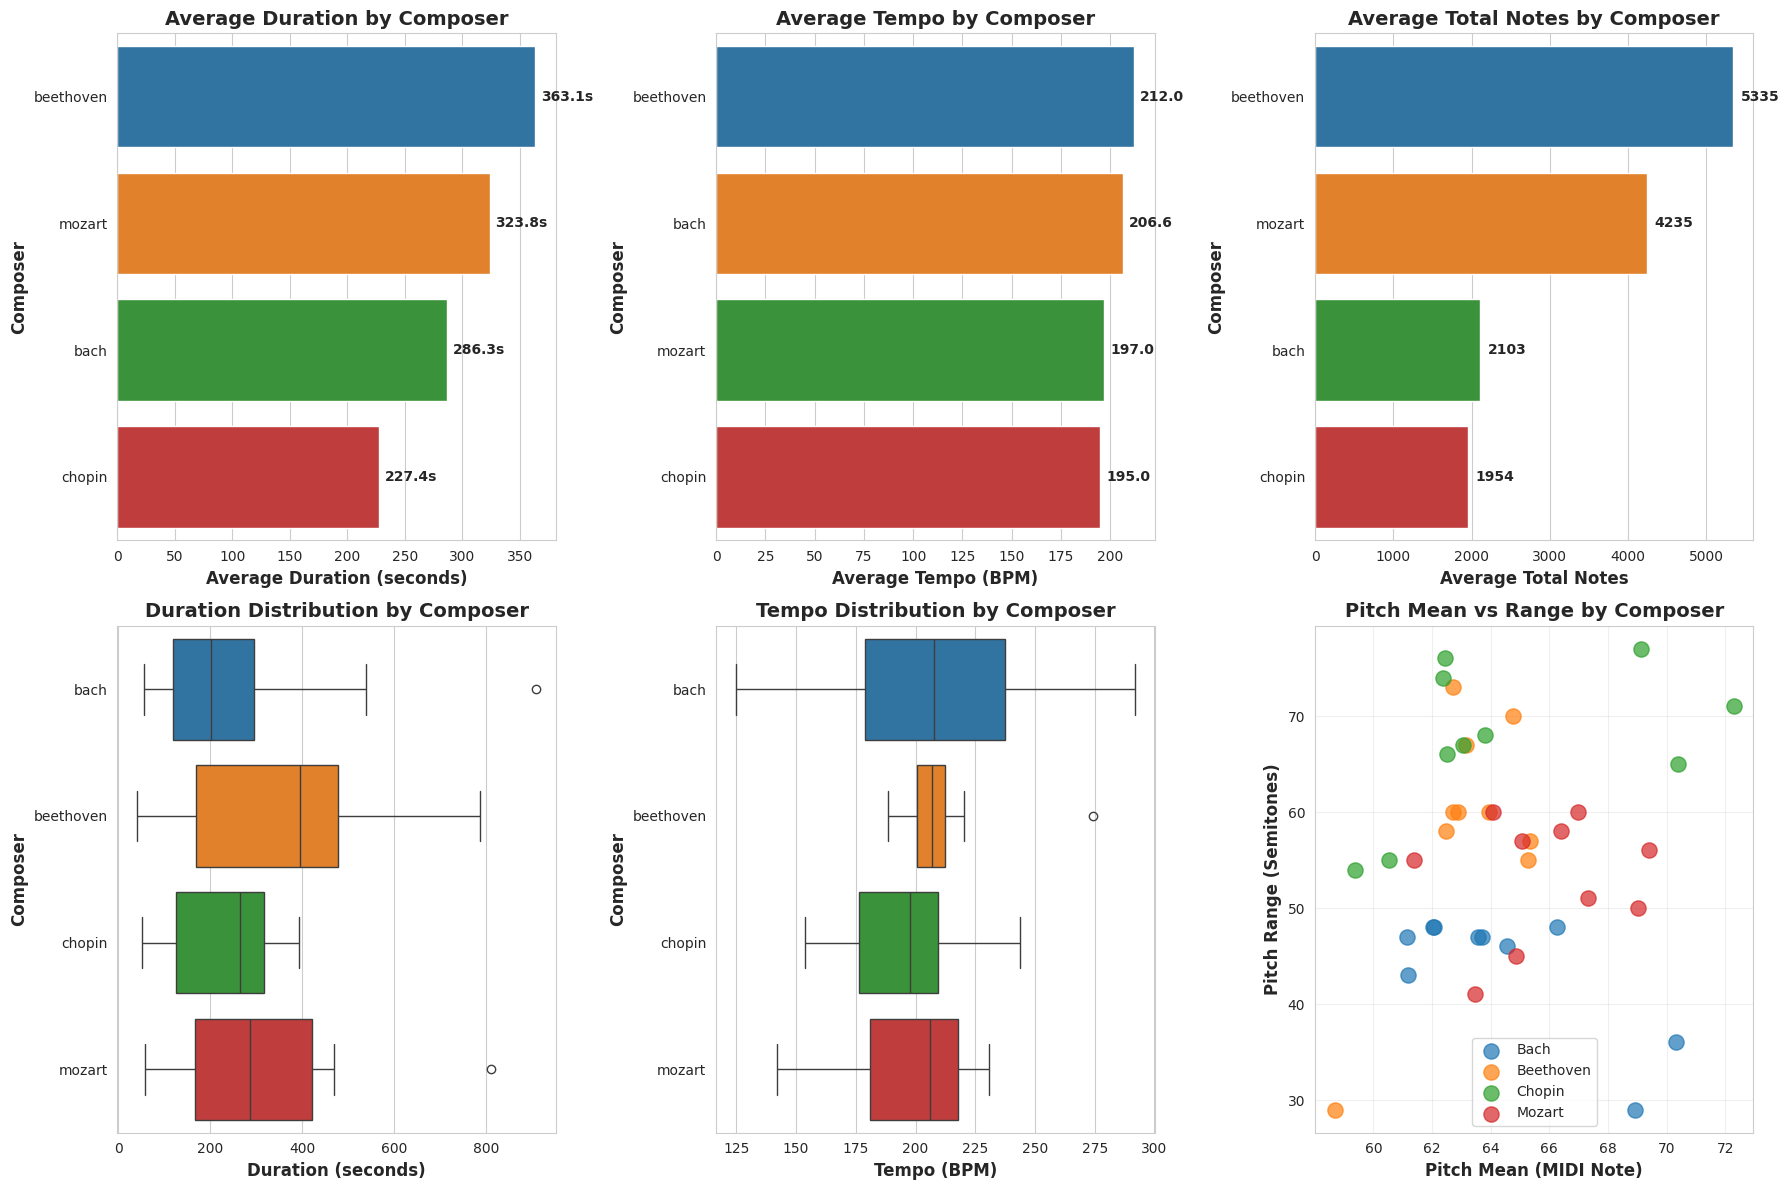


Creating correlation analysis and distribution plots...


/tmp/ipykernel_3200/3745802185.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_stats, y='composer', x='total_notes', ax=ax8, palette=colors)


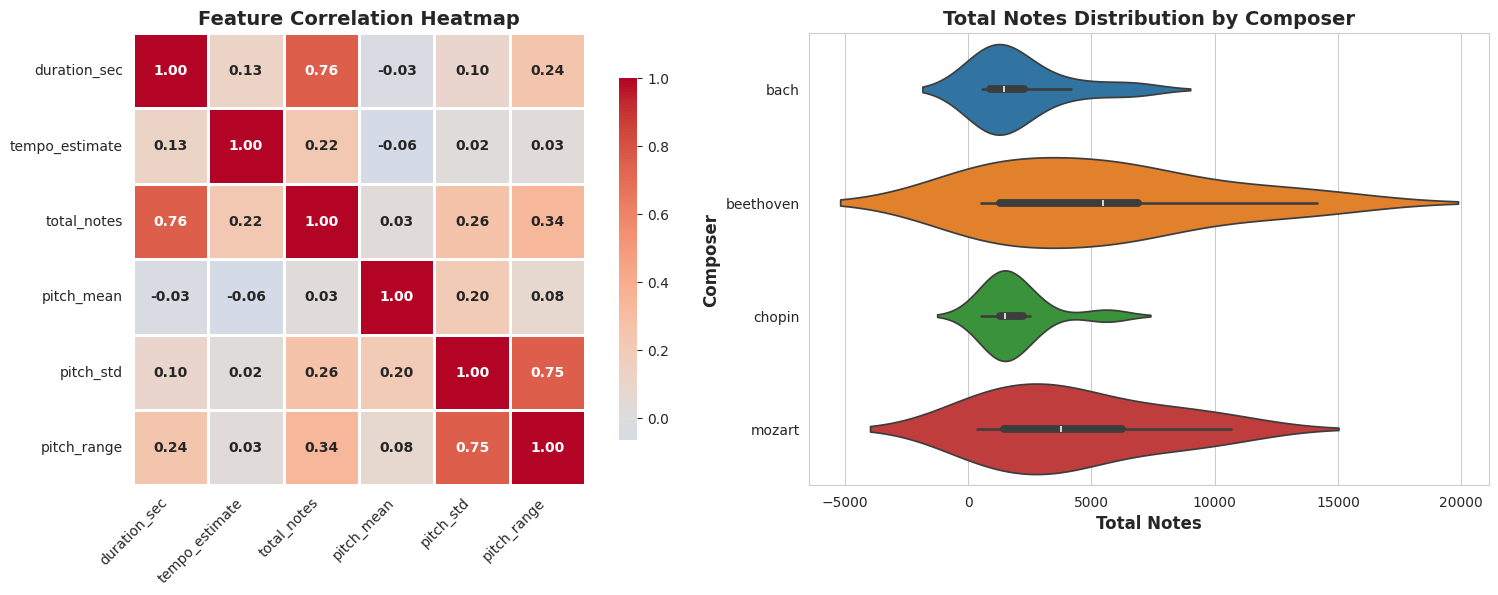


EDA VISUALIZATIONS COMPLETE!

Key Observations:
--------------------------------------------------------------------------------
  • Longest pieces: Beethoven (363.1s average)
  • Fastest tempo: Beethoven (212.0 BPM average)
  • Most complex: Beethoven (5335 notes average)
  • Strongest correlation: Duration & Total Notes (r=0.76)



In [8]:
# Create visualizations for EDA - 4 Composers
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("="*80)
print("CREATING EDA VISUALIZATIONS")
print("="*80)

# Set up the plotting style
sns.set_style("whitegrid")
sns.set_palette("husl")

# Create a figure with multiple subplots
fig = plt.figure(figsize=(18, 12))

# 1. Average Duration by Composer
ax1 = plt.subplot(2, 3, 1)
df_duration = df_stats.groupby('composer')['duration_sec'].mean().sort_values(ascending=False)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
sns.barplot(x=df_duration.values, y=df_duration.index, ax=ax1, palette=colors)
ax1.set_xlabel('Average Duration (seconds)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Composer', fontsize=12, fontweight='bold')
ax1.set_title('Average Duration by Composer', fontsize=14, fontweight='bold')
for i, v in enumerate(df_duration.values):
    ax1.text(v + 5, i, f'{v:.1f}s', va='center', fontweight='bold')

# 2. Average Tempo by Composer
ax2 = plt.subplot(2, 3, 2)
df_tempo = df_stats.groupby('composer')['tempo_estimate'].mean().sort_values(ascending=False)
sns.barplot(x=df_tempo.values, y=df_tempo.index, ax=ax2, palette=colors)
ax2.set_xlabel('Average Tempo (BPM)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Composer', fontsize=12, fontweight='bold')
ax2.set_title('Average Tempo by Composer', fontsize=14, fontweight='bold')
for i, v in enumerate(df_tempo.values):
    ax2.text(v + 3, i, f'{v:.1f}', va='center', fontweight='bold')

# 3. Average Total Notes by Composer
ax3 = plt.subplot(2, 3, 3)
df_notes = df_stats.groupby('composer')['total_notes'].mean().sort_values(ascending=False)
sns.barplot(x=df_notes.values, y=df_notes.index, ax=ax3, palette=colors)
ax3.set_xlabel('Average Total Notes', fontsize=12, fontweight='bold')
ax3.set_ylabel('Composer', fontsize=12, fontweight='bold')
ax3.set_title('Average Total Notes by Composer', fontsize=14, fontweight='bold')
for i, v in enumerate(df_notes.values):
    ax3.text(v + 100, i, f'{int(v)}', va='center', fontweight='bold')

# 4. Box Plot - Duration Distribution
ax4 = plt.subplot(2, 3, 4)
sns.boxplot(data=df_stats, y='composer', x='duration_sec', ax=ax4, palette=colors)
ax4.set_xlabel('Duration (seconds)', fontsize=12, fontweight='bold')
ax4.set_ylabel('Composer', fontsize=12, fontweight='bold')
ax4.set_title('Duration Distribution by Composer', fontsize=14, fontweight='bold')

# 5. Box Plot - Tempo Distribution
ax5 = plt.subplot(2, 3, 5)
sns.boxplot(data=df_stats, y='composer', x='tempo_estimate', ax=ax5, palette=colors)
ax5.set_xlabel('Tempo (BPM)', fontsize=12, fontweight='bold')
ax5.set_ylabel('Composer', fontsize=12, fontweight='bold')
ax5.set_title('Tempo Distribution by Composer', fontsize=14, fontweight='bold')

# 6. Scatter Plot - Pitch Mean vs Range
ax6 = plt.subplot(2, 3, 6)
for idx, composer in enumerate(sorted(df_stats['composer'].unique())):
    composer_data = df_stats[df_stats['composer'] == composer]
    ax6.scatter(composer_data['pitch_mean'], composer_data['pitch_range'],
                label=composer.title(), s=120, alpha=0.7, color=colors[idx])
ax6.set_xlabel('Pitch Mean (MIDI Note)', fontsize=12, fontweight='bold')
ax6.set_ylabel('Pitch Range (Semitones)', fontsize=12, fontweight='bold')
ax6.set_title('Pitch Mean vs Range by Composer', fontsize=14, fontweight='bold')
ax6.legend(fontsize=10, loc='best')
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Second figure - Correlation heatmap and additional analysis
print("\nCreating correlation analysis and distribution plots...")

fig2 = plt.figure(figsize=(16, 6))

# 1. Correlation Heatmap
ax7 = plt.subplot(1, 2, 1)
numeric_cols = ['duration_sec', 'tempo_estimate', 'total_notes', 'pitch_mean', 'pitch_std', 'pitch_range']
corr_matrix = df_stats[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=2, cbar_kws={"shrink": 0.8}, ax=ax7, annot_kws={'fontsize': 10, 'fontweight': 'bold'})
ax7.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
ax7.set_xticklabels(ax7.get_xticklabels(), rotation=45, ha='right')
ax7.set_yticklabels(ax7.get_yticklabels(), rotation=0)

# 2. Violin Plot - Total Notes Distribution
ax8 = plt.subplot(1, 2, 2)
sns.violinplot(data=df_stats, y='composer', x='total_notes', ax=ax8, palette=colors)
ax8.set_xlabel('Total Notes', fontsize=12, fontweight='bold')
ax8.set_ylabel('Composer', fontsize=12, fontweight='bold')
ax8.set_title('Total Notes Distribution by Composer', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("EDA VISUALIZATIONS COMPLETE!")
print("="*80)

print("\nKey Observations:")
print("-" * 80)
print(f"  • Longest pieces: {df_duration.index[0].title()} ({df_duration.values[0]:.1f}s average)")
print(f"  • Fastest tempo: {df_tempo.index[0].title()} ({df_tempo.values[0]:.1f} BPM average)")
print(f"  • Most complex: {df_notes.index[0].title()} ({int(df_notes.values[0])} notes average)")
print(f"  • Strongest correlation: Duration & Total Notes (r={corr_matrix.loc['duration_sec', 'total_notes']:.2f})")

print("\n" + "="*80)

## 2.2 Data Pre-processing:

Convert the musical scores into a format suitable for deep learning models. This involves converting the musical scores into MIDI files and applying data augmentation techniques.

In [9]:
# Data Pre-Processing: Convert MIDI to sequences and apply augmentation - 4 Composers
import pretty_midi
import numpy as np
import pandas as pd
from collections import Counter
import os
import random
from sklearn.model_selection import train_test_split

print("="*80)
print("MIDI DATA PRE-PROCESSING - 4 COMPOSERS")
print("="*80)

# Configuration
SEQUENCE_LENGTH = 100  # Number of notes in each sequence
TRAIN_SPLIT = 0.7      # 70% training
DEV_SPLIT = 0.15       # 15% development
TEST_SPLIT = 0.15      # 15% test

# Create composer to label mapping (4 composers only)
composers = ['bach', 'beethoven', 'chopin', 'mozart']
composer_to_label = {composer: idx for idx, composer in enumerate(composers)}
label_to_composer = {idx: composer for composer, idx in composer_to_label.items()}

print(f"\nComposer Label Mapping:")
for composer, label in composer_to_label.items():
    print(f"  {label}: {composer.title()}")

def extract_notes_from_midi(midi_path):
    try:
        midi_data = pretty_midi.PrettyMIDI(midi_path)
        notes = []
        for instrument in midi_data.instruments:
            if not instrument.is_drum:
                for note in instrument.notes:
                    notes.append({
                        'pitch': note.pitch,
                        'start': note.start,
                        'end': note.end,
                        'duration': note.end - note.start,
                        'velocity': note.velocity
                    })
        notes = sorted(notes, key=lambda x: x['start'])
        return notes
    except:
        return None

def notes_to_sequences(notes, sequence_length=100):
    if not notes or len(notes) < sequence_length:
        return []
    sequences = []
    for i in range(0, len(notes) - sequence_length + 1, sequence_length // 2):
        seq = notes[i:i + sequence_length]
        sequence_array = np.array([
            [n['pitch'] / 127.0,
             min(n['duration'], 4.0) / 4.0,
             n['velocity'] / 127.0]
            for n in seq
        ])
        sequences.append(sequence_array)
    return sequences

# Process all composers
print("\n" + "="*80)
print("EXTRACTING SEQUENCES FROM ALL COMPOSERS")
print("="*80)

all_sequences = []
all_labels = []

for composer in composers:
    all_folders = [f for f in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, f))]
    matching_folders = [f for f in all_folders if f.lower() == composer.lower()]

    if not matching_folders:
        print(f"\n✗ {composer.title()}: Folder not found")
        continue

    composer_folder = matching_folders[0]
    composer_path = os.path.join(dataset_path, composer_folder)

    midi_files = [f for f in os.listdir(composer_path) if f.endswith('.mid') or f.endswith('.midi')]
    print(f"\n{composer.title()}: Processing {len(midi_files)} MIDI files...")

    composer_sequences = 0
    for midi_file in midi_files:
        midi_file_path = os.path.join(composer_path, midi_file)
        notes = extract_notes_from_midi(midi_file_path)

        if notes:
            sequences = notes_to_sequences(notes, SEQUENCE_LENGTH)
            if sequences:
                all_sequences.extend(sequences)
                all_labels.extend([composer_to_label[composer]] * len(sequences))
                composer_sequences += len(sequences)

    print(f"  ✓ Extracted {composer_sequences} sequences")

print("\n" + "="*80)
print(f"TOTAL SEQUENCES: {len(all_sequences)}")
print("="*80)

# Convert to arrays and split
X_all = np.array(all_sequences)
y_all = np.array(all_labels)

print("\nSplitting data...")
X_train, X_temp, y_train, y_temp = train_test_split(
    X_all, y_all, test_size=0.3, random_state=42, stratify=y_all
)
X_dev, X_test, y_dev, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# Simple augmentation for training set
print("\nApplying augmentation...")
augmented_X = []
augmented_y = []
for i in range(len(X_train)):
    augmented_X.append(X_train[i])
    augmented_y.append(y_train[i])
    # Pitch shift
    for shift in [-0.02, 0.02]:
        aug = X_train[i].copy()
        aug[:, 0] = np.clip(aug[:, 0] + shift, 0, 1)
        augmented_X.append(aug)
        augmented_y.append(y_train[i])

X_train = np.array(augmented_X)
y_train = np.array(augmented_y)

print("\n" + "="*80)
print("DATA PRE-PROCESSING COMPLETE")
print("="*80)
print(f"\nTraining: {X_train.shape} ({len(X_train)} sequences)")
print(f"Dev: {X_dev.shape} ({len(X_dev)} sequences)")
print(f"Test: {X_test.shape} ({len(X_test)} sequences)")

print("\nClass Distribution (Training):")
train_dist = Counter(y_train)
for label in sorted(train_dist.keys()):
    print(f"  {label_to_composer[label].title()}: {train_dist[label]}")

print("\n" + "="*80)

MIDI DATA PRE-PROCESSING - 4 COMPOSERS

Composer Label Mapping:
  0: Bach
  1: Beethoven
  2: Chopin
  3: Mozart

EXTRACTING SEQUENCES FROM ALL COMPOSERS

Bach: Processing 122 MIDI files...


/usr/local/lib/python3.12/dist-packages/pretty_midi/pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(


  ✓ Extracted 6613 sequences

Beethoven: Processing 133 MIDI files...
  ✓ Extracted 13302 sequences

Chopin: Processing 136 MIDI files...
  ✓ Extracted 6192 sequences

Mozart: Processing 90 MIDI files...
  ✓ Extracted 6861 sequences

TOTAL SEQUENCES: 32968

Splitting data...

Applying augmentation...

DATA PRE-PROCESSING COMPLETE

Training: (69231, 100, 3) (69231 sequences)
Dev: (4945, 100, 3) (4945 sequences)
Test: (4946, 100, 3) (4946 sequences)

Class Distribution (Training):
  Bach: 13887
  Beethoven: 27933
  Chopin: 13002
  Mozart: 14409



## 3. Feature Extraction:

Extract features from the MIDI files, such as notes, chords, and tempo, using music analysis tools.

In [10]:
# Feature Extraction: Prepare FULL Piano Rolls for CNN + Summary Statistics
import pretty_midi
import numpy as np
import pandas as pd
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

print("="*80)
print("FEATURE EXTRACTION - PIANO ROLLS FOR CNN + STATISTICS")
print("="*80)

# Configuration for CNN
FRAME_RATE = 16  # Hz - frames per second
MIN_MIDI_PITCH = 21   # A0 - lowest note on piano
MAX_MIDI_PITCH = 108  # C8 - highest note on piano
PITCH_RANGE = MAX_MIDI_PITCH - MIN_MIDI_PITCH + 1  # 88 keys
MAX_TIME_STEPS = 500  # Maximum time steps for CNN (pad/truncate)

composers = ['bach', 'beethoven', 'chopin', 'mozart']
composer_to_label = {composer: idx for idx, composer in enumerate(composers)}

print(f"\nConfiguration:")
print(f"  Frame Rate: {FRAME_RATE} Hz")
print(f"  Pitch Range: {MIN_MIDI_PITCH}-{MAX_MIDI_PITCH} ({PITCH_RANGE} keys)")
print(f"  Max Time Steps: {MAX_TIME_STEPS}")
print(f"  Composers: {', '.join([c.title() for c in composers])}")

def extract_piano_roll(midi_data, frame_rate=16, max_time_steps=500):
    """Extract piano roll representation for CNN models."""
    try:
        piano_roll_full = midi_data.get_piano_roll(fs=frame_rate)
        piano_roll = piano_roll_full[MIN_MIDI_PITCH:MAX_MIDI_PITCH+1, :].T
        piano_roll = piano_roll / 127.0  # Normalize to [0, 1]

        # Pad or truncate to fixed length
        if piano_roll.shape[0] < max_time_steps:
            # Pad with zeros
            padding = np.zeros((max_time_steps - piano_roll.shape[0], PITCH_RANGE))
            piano_roll = np.vstack([piano_roll, padding])
        else:
            # Truncate
            piano_roll = piano_roll[:max_time_steps, :]

        return piano_roll
    except:
        return None

# Extract piano rolls from ALL files for CNN training
print("\n" + "="*80)
print("EXTRACTING PIANO ROLLS FROM ALL FILES (FOR CNN)")
print("="*80)

all_piano_rolls = []
all_labels_cnn = []
file_metadata = []

for composer in composers:
    all_folders = [f for f in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, f))]
    matching_folders = [f for f in all_folders if f.lower() == composer.lower()]

    if not matching_folders:
        print(f"\n✗ {composer.title()}: Folder not found")
        continue

    composer_folder = matching_folders[0]
    composer_path = os.path.join(dataset_path, composer_folder)
    midi_files = [f for f in os.listdir(composer_path) if f.endswith('.mid') or f.endswith('.midi')]

    print(f"\n{composer.title()}: Processing {len(midi_files)} files...")

    processed = 0
    for midi_file in midi_files:
        try:
            midi_file_path = os.path.join(composer_path, midi_file)
            midi_data = pretty_midi.PrettyMIDI(midi_file_path)

            # Extract piano roll
            piano_roll = extract_piano_roll(midi_data, FRAME_RATE, MAX_TIME_STEPS)

            if piano_roll is not None and piano_roll.shape == (MAX_TIME_STEPS, PITCH_RANGE):
                all_piano_rolls.append(piano_roll)
                all_labels_cnn.append(composer_to_label[composer])

                # Store metadata for analysis
                file_metadata.append({
                    'composer': composer,
                    'file': midi_file,
                    'duration': midi_data.get_end_time(),
                    'tempo': midi_data.estimate_tempo(),
                    'n_instruments': len(midi_data.instruments)
                })

                processed += 1

        except Exception as e:
            continue

    print(f"  ✓ Extracted {processed} piano rolls")

print("\n" + "="*80)
print(f"TOTAL PIANO ROLLS EXTRACTED: {len(all_piano_rolls)}")
print("="*80)

# Convert to numpy arrays
X_cnn_all = np.array(all_piano_rolls)
y_cnn_all = np.array(all_labels_cnn)

print(f"\nPiano Roll Dataset Shape: {X_cnn_all.shape}")
print(f"  - Samples: {X_cnn_all.shape[0]}")
print(f"  - Time Steps: {X_cnn_all.shape[1]}")
print(f"  - Pitch Range (Piano Keys): {X_cnn_all.shape[2]}")

# Split into train/dev/test (same ratios as Cell 12)
print("\n" + "="*80)
print("SPLITTING CNN DATA (TRAIN/DEV/TEST)")
print("="*80)

X_train_cnn, X_temp_cnn, y_train_cnn, y_temp_cnn = train_test_split(
    X_cnn_all, y_cnn_all, test_size=0.3, random_state=42, stratify=y_cnn_all
)

X_dev_cnn, X_test_cnn, y_dev_cnn, y_test_cnn = train_test_split(
    X_temp_cnn, y_temp_cnn, test_size=0.5, random_state=42, stratify=y_temp_cnn
)

# Reshape for CNN: (samples, time_steps, features, channels)
X_train_cnn = X_train_cnn.reshape(-1, MAX_TIME_STEPS, PITCH_RANGE, 1)
X_dev_cnn = X_dev_cnn.reshape(-1, MAX_TIME_STEPS, PITCH_RANGE, 1)
X_test_cnn = X_test_cnn.reshape(-1, MAX_TIME_STEPS, PITCH_RANGE, 1)

print("\nCNN Data Shapes:")
print(f"  Training:   {X_train_cnn.shape}")
print(f"  Dev:        {X_dev_cnn.shape}")
print(f"  Test:       {X_test_cnn.shape}")

print("\nClass Distribution (CNN Training):")
from collections import Counter
train_dist_cnn = Counter(y_train_cnn)
label_to_composer = {idx: composer for composer, idx in composer_to_label.items()}
for label in sorted(train_dist_cnn.keys()):
    print(f"  {label_to_composer[label].title()}: {train_dist_cnn[label]} samples")

# Create summary statistics DataFrame
print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)

if file_metadata:
    df_features = pd.DataFrame(file_metadata)

    print("\nFeature Summary by Composer:")
    print("-" * 80)

    summary = df_features.groupby('composer').agg({
        'duration': ['mean', 'std', 'min', 'max'],
        'tempo': ['mean', 'std', 'min', 'max'],
        'n_instruments': ['mean', 'max']
    }).round(2)

    display(summary)

print("\n" + "="*80)
print("FEATURE EXTRACTION COMPLETE!")
print("="*80)

print("\n📊 Data Available for Model Building:")
print("-" * 80)
print("\n✅ LSTM/Transformer (from Cell 12):")
print(f"   - X_train: {X_train.shape} (sequences, notes, features)")
print(f"   - X_dev:   {X_dev.shape}")
print(f"   - X_test:  {X_test.shape}")

print("\n✅ CNN (from this cell):")
print(f"   - X_train_cnn: {X_train_cnn.shape} (samples, time, keys, channels)")
print(f"   - X_dev_cnn:   {X_dev_cnn.shape}")
print(f"   - X_test_cnn:  {X_test_cnn.shape}")

print("\n" + "="*80)
print("🎯 READY FOR MODEL BUILDING: LSTM, CNN, and Transformer!")
print("="*80)

FEATURE EXTRACTION - PIANO ROLLS FOR CNN + STATISTICS

Configuration:
  Frame Rate: 16 Hz
  Pitch Range: 21-108 (88 keys)
  Max Time Steps: 500
  Composers: Bach, Beethoven, Chopin, Mozart

EXTRACTING PIANO ROLLS FROM ALL FILES (FOR CNN)

Bach: Processing 122 files...


/usr/local/lib/python3.12/dist-packages/pretty_midi/pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(


  ✓ Extracted 122 piano rolls

Beethoven: Processing 133 files...
  ✓ Extracted 132 piano rolls

Chopin: Processing 136 files...
  ✓ Extracted 136 piano rolls

Mozart: Processing 90 files...
  ✓ Extracted 90 piano rolls

TOTAL PIANO ROLLS EXTRACTED: 480

Piano Roll Dataset Shape: (480, 500, 88)
  - Samples: 480
  - Time Steps: 500
  - Pitch Range (Piano Keys): 88

SPLITTING CNN DATA (TRAIN/DEV/TEST)

CNN Data Shapes:
  Training:   (336, 500, 88, 1)
  Dev:        (72, 500, 88, 1)
  Test:       (72, 500, 88, 1)

Class Distribution (CNN Training):
  Bach: 85 samples
  Beethoven: 93 samples
  Chopin: 95 samples
  Mozart: 63 samples

SUMMARY STATISTICS

Feature Summary by Composer:
--------------------------------------------------------------------------------


duration                           tempo                         \
              mean     std    min      max    mean    std     min     max   
composer                                                                    
bach        344.39  294.87  42.11  1179.42  199.95  40.98  101.37  291.74   
beethoven   386.58  499.08  21.87  5032.31  196.18  39.10   58.00  281.71   
chopin      220.83  184.50  23.31  1352.74  192.39  37.04   52.29  277.69   
mozart      286.66  180.31  34.90   896.52  196.53  40.29   68.00  273.66   

          n_instruments      
                   mean max  
composer                     
bach               3.93  37  
beethoven          5.53  29  
chopin             2.45  20  
mozart             7.24  19


FEATURE EXTRACTION COMPLETE!

📊 Data Available for Model Building:
--------------------------------------------------------------------------------

✅ LSTM/Transformer (from Cell 12):
   - X_train: (69231, 100, 3) (sequences, notes, features)
   - X_dev:   (4945, 100, 3)
   - X_test:  (4946, 100, 3)

✅ CNN (from this cell):
   - X_train_cnn: (336, 500, 88, 1) (samples, time, keys, channels)
   - X_dev_cnn:   (72, 500, 88, 1)
   - X_test_cnn:  (72, 500, 88, 1)

🎯 READY FOR MODEL BUILDING: LSTM, CNN, and Transformer!


4. Model Building: Develop a deep learning model using LSTM and CNN architectures to classify the musical scores according to the composer.

## 4.1 LSTM


In [ ]:
#

## 4.2 CNN

## 4.3 Transformer

TRANSFORMER MODEL FOR COMPOSER CLASSIFICATION

TensorFlow version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

Model Configuration:
  Sequence Length: 100
  Input Features: 3
  Embedding Dimension (d_model): 128
  Attention Heads: 8
  Feed-Forward Dimension: 512
  Transformer Blocks: 4
  Dropout Rate: 0.3

BUILDING TRANSFORMER MODEL

✓ Transformer model built successfully!

Model Summary:


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100, 3)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100, 128)       │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ positional_encoding             │ (None, 100, 128)       │             0 │
│ (PositionalEncoding)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ (None, 100, 128)       │       659,712 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 100, 128)       │       659,712 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_2             │ (None, 100, 128)       │       659,712 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_3             │ (None, 100, 128)       │       659,712 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,656,388 (10.13 MB)

 Trainable params: 2,656,388 (10.13 MB)

 Non-trainable params: 0 (0.00 B)


📊 Total Parameters: 2,656,388

TRAINING TRANSFORMER MODEL

Training Configuration:
  Batch Size: 128
  Max Epochs: 50
  Early Stopping Patience: 10

Dataset Sizes:
  Training samples: 69,231
  Dev samples: 4,945
  Test samples: 4,946

--------------------------------------------------------------------------------
Starting training...
--------------------------------------------------------------------------------
Epoch 1/50
541/541 ━━━━━━━━━━━━━━━━━━━━ 88s 89ms/step - accuracy: 0.3838 - loss: 1.2772 - val_accuracy: 0.4024 - val_loss: 1.2405 - learning_rate: 1.0000e-04
Epoch 2/50
541/541 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.4180 - loss: 1.2322 - val_accuracy: 0.4427 - val_loss: 1.1931 - learning_rate: 1.0000e-04
Epoch 3/50
541/541 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.4793 - loss: 1.1545 - val_accuracy: 0.5286 - val_loss: 1.0688 - learning_rate: 1.0000e-04
Epoch 4/50
541/541 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.5416 - loss: 1.0713 - val_accuracy: 0.5

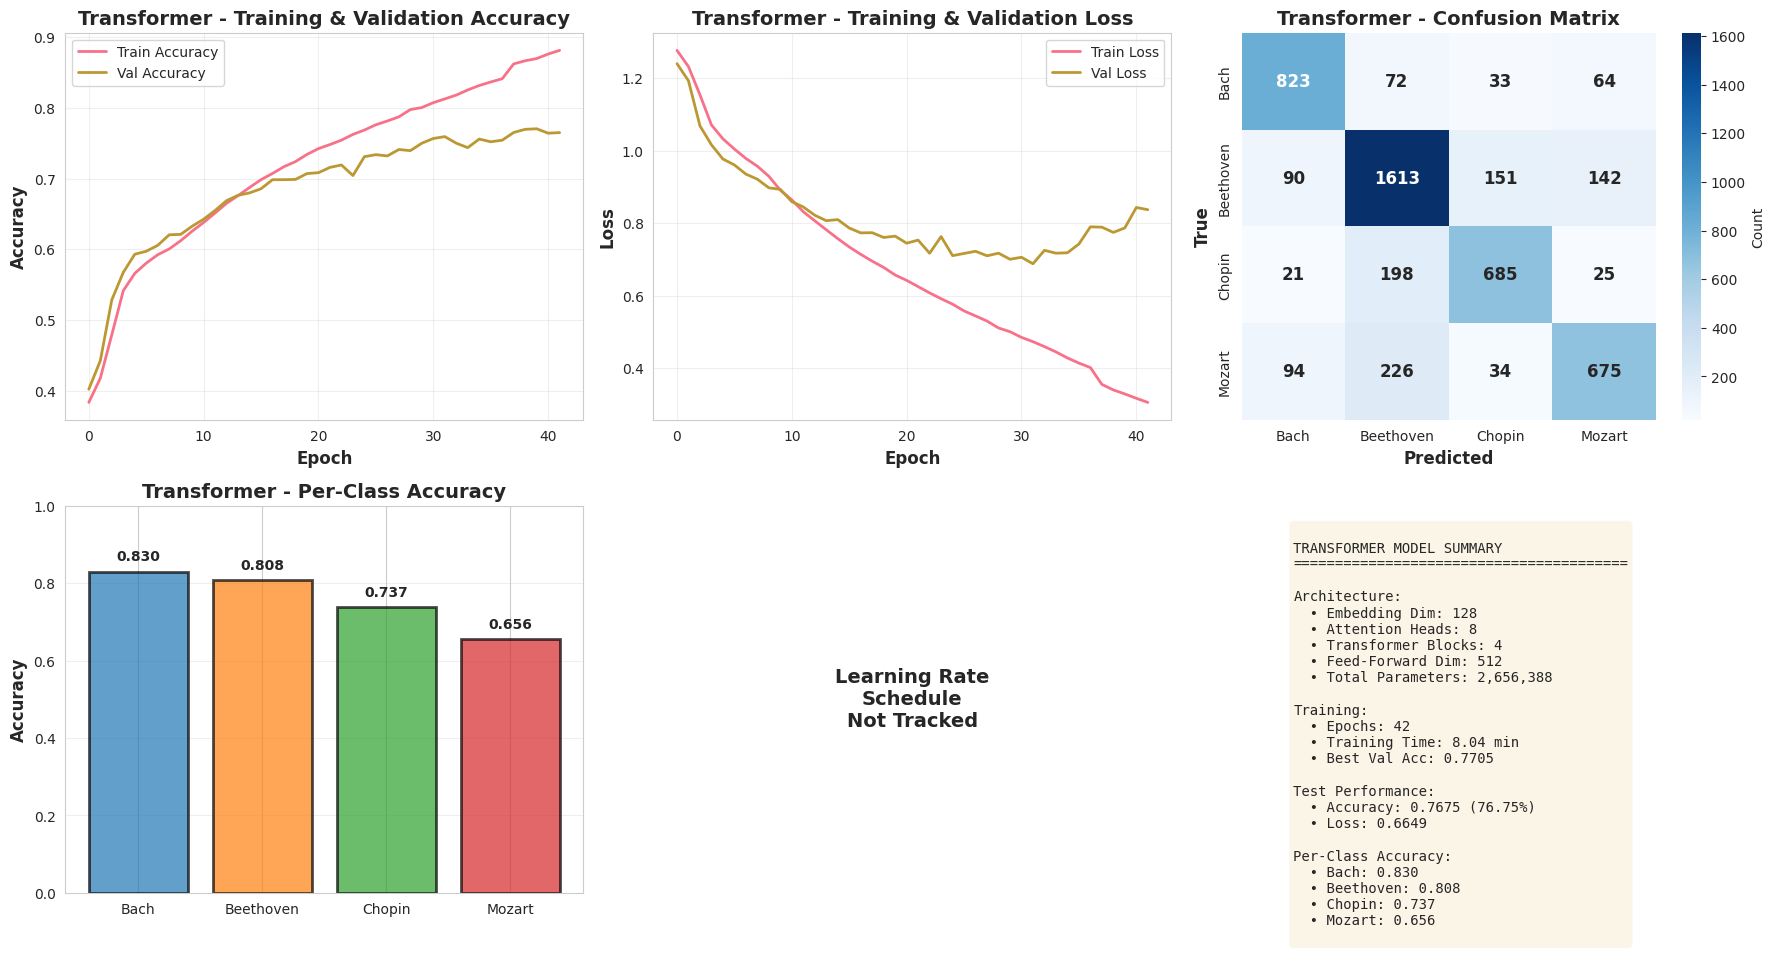


✓ Visualizations complete!

SAVING TRANSFORMER MODEL

✓ Model saved to: /Workspace/Users/mzamaniturk@sandiego.edu/aai-511-final-project-group1/models/transformer_model.keras

TRANSFORMER MODEL TRAINING COMPLETE!

🎯 Final Test Accuracy: 76.75%
📊 Model: /Workspace/Users/mzamaniturk@sandiego.edu/aai-511-final-project-group1/models/transformer_model.keras


In [11]:
# Transformer Model for Music Composer Classification
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import time

print("="*80)
print("TRANSFORMER MODEL FOR COMPOSER CLASSIFICATION")
print("="*80)

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f"\nTensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

# Model Configuration
SEQ_LENGTH = 100      # Number of notes in sequence
INPUT_DIM = 3         # Features per note (pitch, duration, velocity)
NUM_CLASSES = 4       # 4 composers
D_MODEL = 128         # Embedding dimension
NUM_HEADS = 8         # Number of attention heads
FF_DIM = 512          # Feed-forward dimension
NUM_TRANSFORMER_BLOCKS = 4  # Number of transformer blocks
DROPOUT_RATE = 0.3

print("\nModel Configuration:")
print(f"  Sequence Length: {SEQ_LENGTH}")
print(f"  Input Features: {INPUT_DIM}")
print(f"  Embedding Dimension (d_model): {D_MODEL}")
print(f"  Attention Heads: {NUM_HEADS}")
print(f"  Feed-Forward Dimension: {FF_DIM}")
print(f"  Transformer Blocks: {NUM_TRANSFORMER_BLOCKS}")
print(f"  Dropout Rate: {DROPOUT_RATE}")

# Positional Encoding
class PositionalEncoding(layers.Layer):
    def __init__(self, sequence_length, d_model):
        super().__init__()
        self.sequence_length = sequence_length
        self.d_model = d_model

        # Create positional encoding matrix
        position = np.arange(sequence_length)[:, np.newaxis]
        div_term = np.exp(np.arange(0, d_model, 2) * -(np.log(10000.0) / d_model))

        pe = np.zeros((sequence_length, d_model))
        pe[:, 0::2] = np.sin(position * div_term)
        pe[:, 1::2] = np.cos(position * div_term)

        self.positional_encoding = tf.constant(pe, dtype=tf.float32)

    def call(self, x):
        # Add positional encoding to input
        return x + self.positional_encoding

# Transformer Block
class TransformerBlock(layers.Layer):
    def __init__(self, d_model, num_heads, ff_dim, dropout_rate=0.1):
        super().__init__()
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)
        self.ffn = keras.Sequential([
            layers.Dense(ff_dim, activation="relu"),
            layers.Dense(d_model),
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(dropout_rate)
        self.dropout2 = layers.Dropout(dropout_rate)

    def call(self, inputs, training=False):
        # Multi-head attention
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)

        # Feed-forward network
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

# Build Transformer Model
print("\n" + "="*80)
print("BUILDING TRANSFORMER MODEL")
print("="*80)

def build_transformer_model():
    # Input layer
    inputs = layers.Input(shape=(SEQ_LENGTH, INPUT_DIM))

    # Project input features to d_model dimensions
    x = layers.Dense(D_MODEL)(inputs)

    # Add positional encoding
    x = PositionalEncoding(SEQ_LENGTH, D_MODEL)(x)

    # Stack transformer blocks
    for _ in range(NUM_TRANSFORMER_BLOCKS):
        x = TransformerBlock(D_MODEL, NUM_HEADS, FF_DIM, DROPOUT_RATE)(x)

    # Global average pooling
    x = layers.GlobalAveragePooling1D()(x)

    # Dropout
    x = layers.Dropout(DROPOUT_RATE)(x)

    # Dense layer
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(DROPOUT_RATE)(x)

    # Output layer
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

    # Create model
    model = keras.Model(inputs=inputs, outputs=outputs)

    return model

# Create the model
transformer_model = build_transformer_model()

# Compile the model
transformer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\n✓ Transformer model built successfully!")
print("\nModel Summary:")
transformer_model.summary()

# Calculate total parameters
total_params = transformer_model.count_params()
print(f"\n📊 Total Parameters: {total_params:,}")

# Training Configuration
BATCH_SIZE = 128
EPOCHS = 50
EARLY_STOPPING_PATIENCE = 10

print("\n" + "="*80)
print("TRAINING TRANSFORMER MODEL")
print("="*80)
print(f"\nTraining Configuration:")
print(f"  Batch Size: {BATCH_SIZE}")
print(f"  Max Epochs: {EPOCHS}")
print(f"  Early Stopping Patience: {EARLY_STOPPING_PATIENCE}")

print(f"\nDataset Sizes:")
print(f"  Training samples: {len(X_train):,}")
print(f"  Dev samples: {len(X_dev):,}")
print(f"  Test samples: {len(X_test):,}")

# Callbacks
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=EARLY_STOPPING_PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

# Train the model
print("\n" + "-"*80)
print("Starting training...")
print("-"*80)

start_time = time.time()

history = transformer_model.fit(
    X_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_dev, y_dev),
    callbacks=callbacks,
    verbose=1
)

training_time = time.time() - start_time

print("\n" + "="*80)
print("TRAINING COMPLETE!")
print("="*80)
print(f"\n⏱ Training time: {training_time:.2f} seconds ({training_time/60:.2f} minutes)")
print(f"📈 Epochs trained: {len(history.history['loss'])}")
print(f"✓ Best validation accuracy: {max(history.history['val_accuracy']):.4f}")

# Evaluate on test set
print("\n" + "="*80)
print("EVALUATING ON TEST SET")
print("="*80)

test_loss, test_accuracy = transformer_model.evaluate(X_test, y_test, verbose=0)
print(f"\n🎯 Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"📉 Test Loss: {test_loss:.4f}")

# Make predictions
y_pred = transformer_model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)

# Classification Report
composer_names = ['Bach', 'Beethoven', 'Chopin', 'Mozart']
print("\n" + "="*80)
print("CLASSIFICATION REPORT")
print("="*80)
print("\n" + classification_report(y_test, y_pred_classes, target_names=composer_names))

# Confusion Matrix
print("\n" + "="*80)
print("CONFUSION MATRIX")
print("="*80)

cm = confusion_matrix(y_test, y_pred_classes)
print("\n", cm)

# Visualizations
print("\n" + "="*80)
print("CREATING VISUALIZATIONS")
print("="*80)

fig = plt.figure(figsize=(18, 10))

# 1. Training History - Accuracy
ax1 = plt.subplot(2, 3, 1)
ax1.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
ax1.plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax1.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax1.set_title('Transformer - Training & Validation Accuracy', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# 2. Training History - Loss
ax2 = plt.subplot(2, 3, 2)
ax2.plot(history.history['loss'], label='Train Loss', linewidth=2)
ax2.plot(history.history['val_loss'], label='Val Loss', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax2.set_ylabel('Loss', fontsize=12, fontweight='bold')
ax2.set_title('Transformer - Training & Validation Loss', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

# 3. Confusion Matrix Heatmap
ax3 = plt.subplot(2, 3, 3)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=composer_names,
            yticklabels=composer_names, ax=ax3, cbar_kws={'label': 'Count'},
            annot_kws={'fontsize': 12, 'fontweight': 'bold'})
ax3.set_xlabel('Predicted', fontsize=12, fontweight='bold')
ax3.set_ylabel('True', fontsize=12, fontweight='bold')
ax3.set_title('Transformer - Confusion Matrix', fontsize=14, fontweight='bold')

# 4. Per-Class Accuracy
ax4 = plt.subplot(2, 3, 4)
per_class_accuracy = cm.diagonal() / cm.sum(axis=1)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
bars = ax4.bar(composer_names, per_class_accuracy, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax4.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax4.set_title('Transformer - Per-Class Accuracy', fontsize=14, fontweight='bold')
ax4.set_ylim([0, 1.0])
for i, (bar, acc) in enumerate(zip(bars, per_class_accuracy)):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')

# 5. Learning Rate Schedule (if available)
ax5 = plt.subplot(2, 3, 5)
if 'lr' in history.history:
    ax5.plot(history.history['lr'], linewidth=2, color='purple')
    ax5.set_xlabel('Epoch', fontsize=12, fontweight='bold')
    ax5.set_ylabel('Learning Rate', fontsize=12, fontweight='bold')
    ax5.set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
    ax5.set_yscale('log')
    ax5.grid(True, alpha=0.3)
else:
    ax5.text(0.5, 0.5, 'Learning Rate\nSchedule\nNot Tracked',
             ha='center', va='center', fontsize=14, fontweight='bold')
    ax5.axis('off')

# 6. Model Performance Summary
ax6 = plt.subplot(2, 3, 6)
ax6.axis('off')
summary_text = f"""
TRANSFORMER MODEL SUMMARY
{'='*40}

Architecture:
  • Embedding Dim: {D_MODEL}
  • Attention Heads: {NUM_HEADS}
  • Transformer Blocks: {NUM_TRANSFORMER_BLOCKS}
  • Feed-Forward Dim: {FF_DIM}
  • Total Parameters: {total_params:,}

Training:
  • Epochs: {len(history.history['loss'])}
  • Training Time: {training_time/60:.2f} min
  • Best Val Acc: {max(history.history['val_accuracy']):.4f}

Test Performance:
  • Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)
  • Loss: {test_loss:.4f}

Per-Class Accuracy:
  • Bach: {per_class_accuracy[0]:.3f}
  • Beethoven: {per_class_accuracy[1]:.3f}
  • Chopin: {per_class_accuracy[2]:.3f}
  • Mozart: {per_class_accuracy[3]:.3f}
"""
ax6.text(0.1, 0.95, summary_text, fontsize=10, verticalalignment='top',
         fontfamily='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.show()

print("\n✓ Visualizations complete!")

# Save the model
print("\n" + "="*80)
print("SAVING TRANSFORMER MODEL")
print("="*80)

model_save_path = "/Workspace/Users/mzamaniturk@sandiego.edu/aai-511-final-project-group1/models/transformer_model.keras"
import os
os.makedirs(os.path.dirname(model_save_path), exist_ok=True)

transformer_model.save(model_save_path)
print(f"\n✓ Model saved to: {model_save_path}")

print("\n" + "="*80)
print("TRANSFORMER MODEL TRAINING COMPLETE!")
print("="*80)
print(f"\n🎯 Final Test Accuracy: {test_accuracy*100:.2f}%")
print(f"📊 Model: {model_save_path}")
print("="*80)

5. Model Training: Train the deep learning model using the pre-processed and feature-extracted data.

In [ ]:
#

## 5.3. Transformer Model Training

In [12]:
# Transformer Model Training is done in section 4.3
print("Transformer model training was completed in Section 4.3.")

Transformer model training was completed in Section 4.3.


6. Model Evaluation: Evaluate the performance of the deep learning model using accuracy, precision, and recall metrics.

6.3. Transformer Model Evaluation

6. TRANSFORMER MODEL EVALUATION

Overall Test Metrics
----------------------------------------
  Loss:              0.6649
  Accuracy:          0.7675 (76.75%)
  Precision (macro): 0.7673
  Recall (macro):    0.7578
  F1 (macro):        0.7616
  Precision (wgt):   0.7667
  Recall (wgt):      0.7675
  F1 (wgt):          0.7662

CLASSIFICATION REPORT (Precision / Recall / F1)
              precision    recall  f1-score   support

        Bach     0.8006    0.8296    0.8149       992
   Beethoven     0.7648    0.8081    0.7859      1996
      Chopin     0.7586    0.7374    0.7478       929
      Mozart     0.7450    0.6560    0.6977      1029

    accuracy                         0.7675      4946
   macro avg     0.7673    0.7578    0.7616      4946
weighted avg     0.7667    0.7675    0.7662      4946

CONFUSION MATRIX
[[ 823   72   33   64]
 [  90 1613  151  142]
 [  21  198  685   25]
 [  94  226   34  675]]

Per-class accuracy:
  Bach        : 0.8296
  Beethoven   : 0.8081
  Chopin   

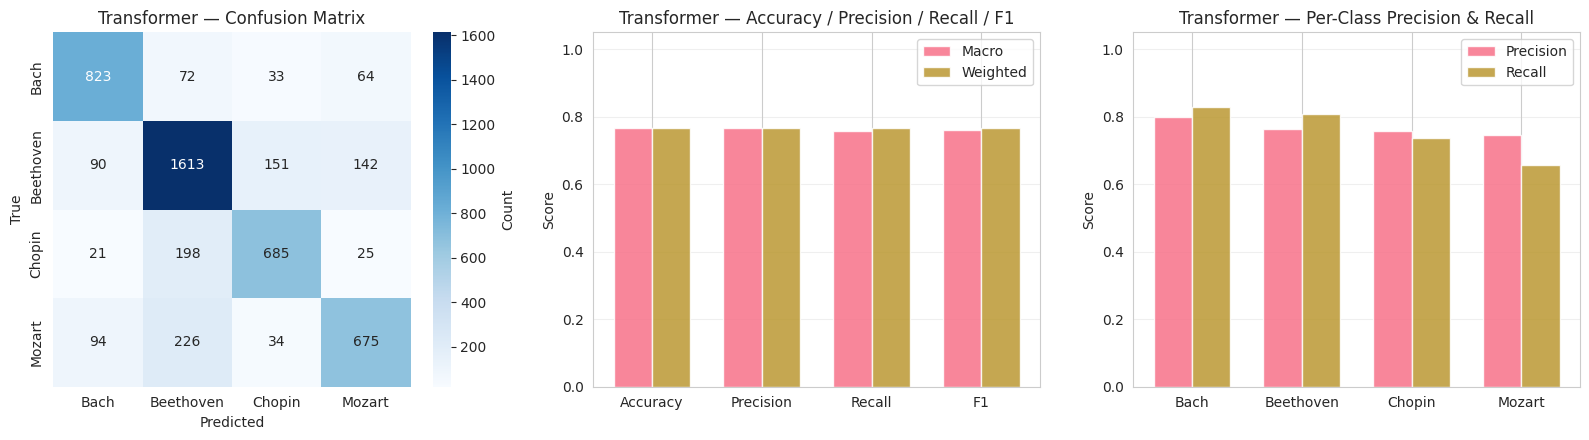

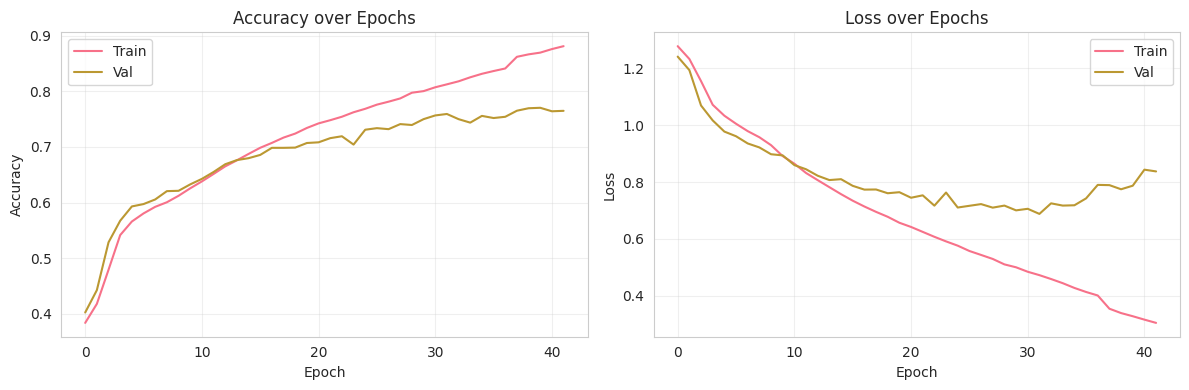


TRANSFORMER EVALUATION COMPLETE
  Accuracy:  76.75%
  Precision: 0.7673 (macro)
  Recall:    0.7578 (macro)
  F1:        0.7616 (macro)


In [13]:
# Transformer Model Evaluation
# Requires: trained `transformer_model` and test data `X_test`, `y_test` from earlier cells

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

print("=" * 80)
print("6. TRANSFORMER MODEL EVALUATION")
print("=" * 80)

composer_names = ["Bach", "Beethoven", "Chopin", "Mozart"]

# Predictions on test set
y_prob = transformer_model.predict(X_test, verbose=0)
y_pred = np.argmax(y_prob, axis=1)
y_true = np.asarray(y_test).ravel()

# Overall metrics
test_loss, test_acc_keras = transformer_model.evaluate(X_test, y_test, verbose=0)
accuracy = accuracy_score(y_true, y_pred)
precision_macro = precision_score(y_true, y_pred, average="macro", zero_division=0)
recall_macro = recall_score(y_true, y_pred, average="macro", zero_division=0)
f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)

precision_weighted = precision_score(y_true, y_pred, average="weighted", zero_division=0)
recall_weighted = recall_score(y_true, y_pred, average="weighted", zero_division=0)
f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)

print("\nOverall Test Metrics")
print("-" * 40)
print(f"  Loss:              {test_loss:.4f}")
print(f"  Accuracy:          {accuracy:.4f} ({accuracy * 100:.2f}%)")
print(f"  Precision (macro): {precision_macro:.4f}")
print(f"  Recall (macro):    {recall_macro:.4f}")
print(f"  F1 (macro):        {f1_macro:.4f}")
print(f"  Precision (wgt):   {precision_weighted:.4f}")
print(f"  Recall (wgt):      {recall_weighted:.4f}")
print(f"  F1 (wgt):          {f1_weighted:.4f}")

# Per-class precision / recall / F1
print("\n" + "=" * 80)
print("CLASSIFICATION REPORT (Precision / Recall / F1)")
print("=" * 80)
print(
    classification_report(
        y_true,
        y_pred,
        target_names=composer_names,
        digits=4,
        zero_division=0,
    )
)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("=" * 80)
print("CONFUSION MATRIX")
print("=" * 80)
print(cm)

per_class_acc = cm.diagonal() / np.maximum(cm.sum(axis=1), 1)
print("\nPer-class accuracy:")
for name, acc in zip(composer_names, per_class_acc):
    print(f"  {name:12s}: {acc:.4f}")

# Visualizations
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=composer_names,
    yticklabels=composer_names,
    ax=axes[0],
    cbar_kws={"label": "Count"},
)
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")
axes[0].set_title("Transformer — Confusion Matrix")

metric_labels = ["Accuracy", "Precision", "Recall", "F1"]
macro_vals = [accuracy, precision_macro, recall_macro, f1_macro]
weighted_vals = [accuracy, precision_weighted, recall_weighted, f1_weighted]
x = np.arange(len(metric_labels))
width = 0.35
axes[1].bar(x - width / 2, macro_vals, width, label="Macro", alpha=0.85)
axes[1].bar(x + width / 2, weighted_vals, width, label="Weighted", alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(metric_labels)
axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel("Score")
axes[1].set_title("Transformer — Accuracy / Precision / Recall / F1")
axes[1].legend()
axes[1].grid(True, axis="y", alpha=0.3)

prec_per = precision_score(y_true, y_pred, average=None, zero_division=0)
rec_per = recall_score(y_true, y_pred, average=None, zero_division=0)
x2 = np.arange(len(composer_names))
axes[2].bar(x2 - width / 2, prec_per, width, label="Precision", alpha=0.85)
axes[2].bar(x2 + width / 2, rec_per, width, label="Recall", alpha=0.85)
axes[2].set_xticks(x2)
axes[2].set_xticklabels(composer_names)
axes[2].set_ylim(0, 1.05)
axes[2].set_ylabel("Score")
axes[2].set_title("Transformer — Per-Class Precision & Recall")
axes[2].legend()
axes[2].grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# Optional: training curves if history is available from training cell
if "history" in dir() and history is not None and hasattr(history, "history"):
    fig2, axes2 = plt.subplots(1, 2, figsize=(12, 4))
    axes2[0].plot(history.history["accuracy"], label="Train")
    axes2[0].plot(history.history["val_accuracy"], label="Val")
    axes2[0].set_title("Accuracy over Epochs")
    axes2[0].set_xlabel("Epoch")
    axes2[0].set_ylabel("Accuracy")
    axes2[0].legend()
    axes2[0].grid(True, alpha=0.3)

    axes2[1].plot(history.history["loss"], label="Train")
    axes2[1].plot(history.history["val_loss"], label="Val")
    axes2[1].set_title("Loss over Epochs")
    axes2[1].set_xlabel("Epoch")
    axes2[1].set_ylabel("Loss")
    axes2[1].legend()
    axes2[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

print("\n" + "=" * 80)
print("TRANSFORMER EVALUATION COMPLETE")
print("=" * 80)
print(f"  Accuracy:  {accuracy * 100:.2f}%")
print(f"  Precision: {precision_macro:.4f} (macro)")
print(f"  Recall:    {recall_macro:.4f} (macro)")
print(f"  F1:        {f1_macro:.4f} (macro)")
print("=" * 80)


SEPARATE ROC GRAPHS (One-vs-Rest per Composer)
  Bach         AUC = 0.9585
  Beethoven    AUC = 0.9051
  Chopin       AUC = 0.9429
  Mozart       AUC = 0.9173


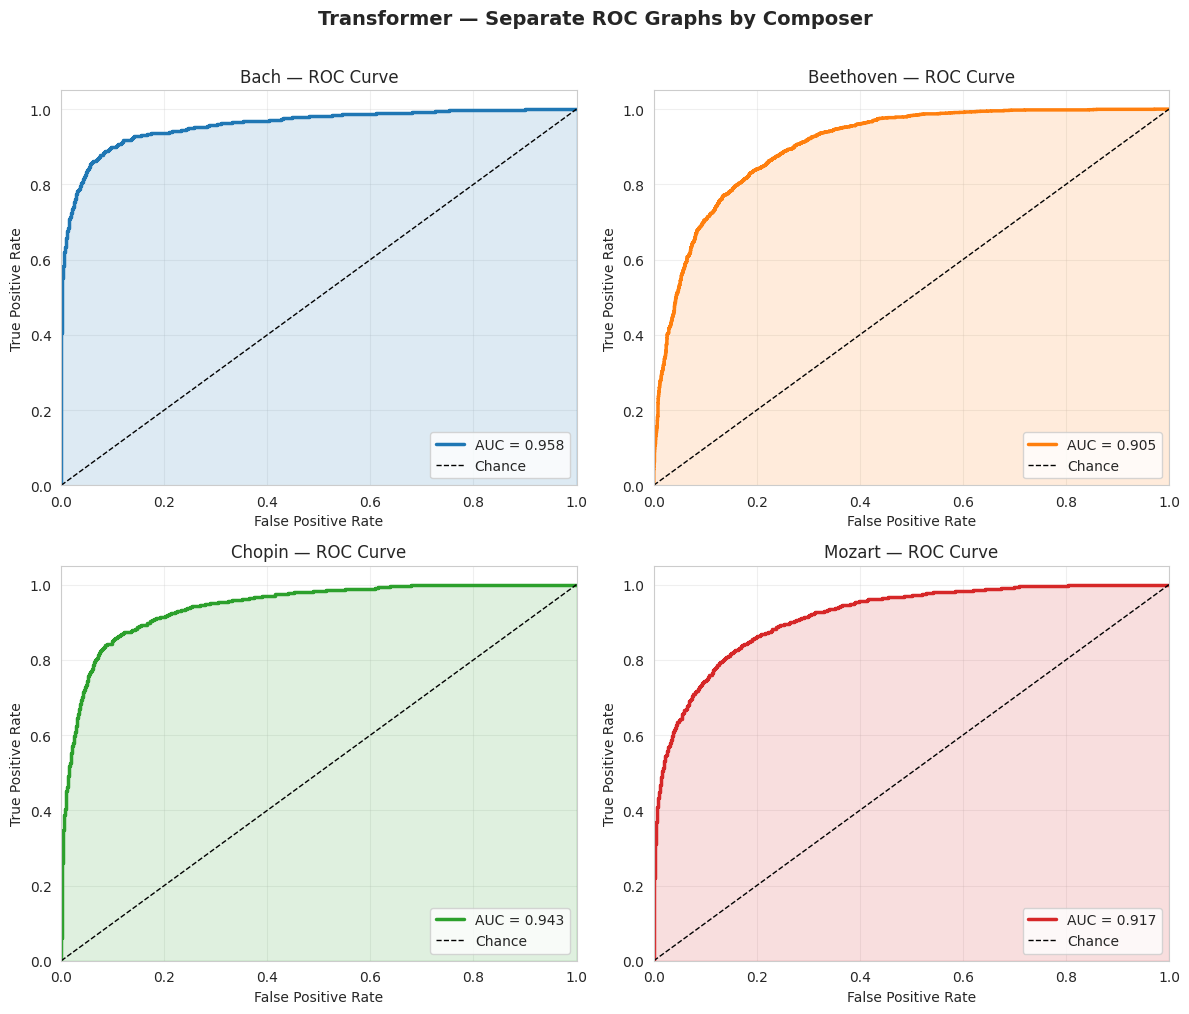


COMBINED ROC GRAPH (All Composers)
  Macro-average AUC = 0.9310
  Micro-average AUC = 0.9375


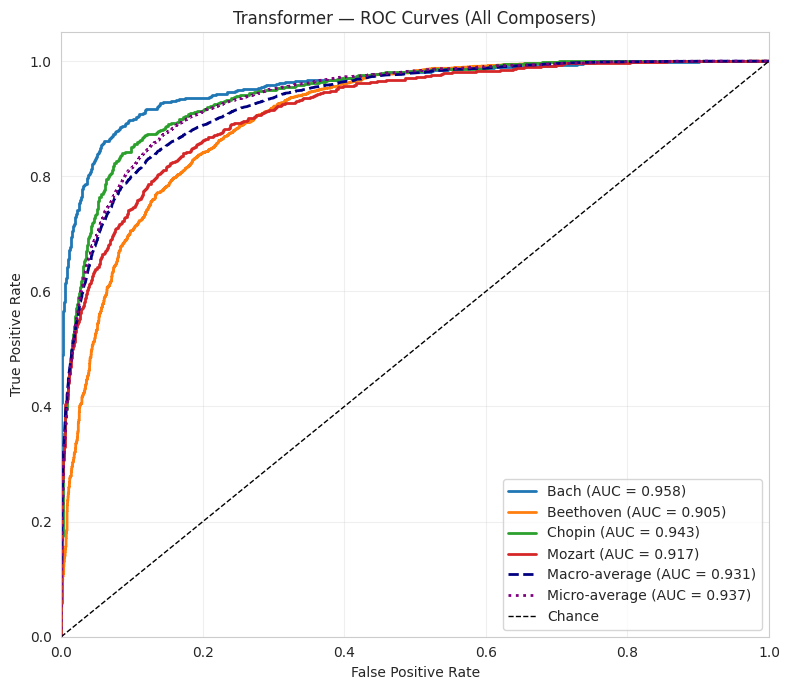

In [15]:
# separate roc graph + combined ROC for all composers
# Requires: trained transformer_model and X_test, y_test (from Section 4.3)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

composer_names = ["Bach", "Beethoven", "Chopin", "Mozart"]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

y_true = np.asarray(y_test).ravel()

# Prefer probabilities from evaluation cell; otherwise predict
if "y_prob" in dir() and y_prob is not None and np.ndim(y_prob) == 2:
    probs = np.asarray(y_prob)
else:
    probs = transformer_model.predict(X_test, verbose=0)

y_true_bin = label_binarize(y_true, classes=list(range(len(composer_names))))
n_classes = len(composer_names)

fpr, tpr, roc_auc = {}, {}, {}

print("=" * 80)
print("SEPARATE ROC GRAPHS (One-vs-Rest per Composer)")
print("=" * 80)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for i, (name, color) in enumerate(zip(composer_names, colors)):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    print(f"  {name:12s} AUC = {roc_auc[i]:.4f}")

    ax = axes[i]
    ax.plot(fpr[i], tpr[i], color=color, lw=2.5, label=f"AUC = {roc_auc[i]:.3f}")
    ax.fill_between(fpr[i], tpr[i], alpha=0.15, color=color)
    ax.plot([0, 1], [0, 1], "k--", lw=1, label="Chance")
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"{name} — ROC Curve")
    ax.legend(loc="lower right")
    ax.grid(True, alpha=0.3)

plt.suptitle("Transformer — Separate ROC Graphs by Composer", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# Macro / micro averages for the combined plot
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_classes
fpr["macro"], tpr["macro"] = all_fpr, mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), probs.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

print("\n" + "=" * 80)
print("COMBINED ROC GRAPH (All Composers)")
print("=" * 80)
print(f"  Macro-average AUC = {roc_auc['macro']:.4f}")
print(f"  Micro-average AUC = {roc_auc['micro']:.4f}")

fig2, ax2 = plt.subplots(figsize=(8, 7))
for i, (name, color) in enumerate(zip(composer_names, colors)):
    ax2.plot(
        fpr[i], tpr[i], color=color, lw=2,
        label=f"{name} (AUC = {roc_auc[i]:.3f})",
    )
ax2.plot(
    fpr["macro"], tpr["macro"], color="navy", lw=2, linestyle="--",
    label=f"Macro-average (AUC = {roc_auc['macro']:.3f})",
)
ax2.plot(
    fpr["micro"], tpr["micro"], color="purple", lw=2, linestyle=":",
    label=f"Micro-average (AUC = {roc_auc['micro']:.3f})",
)
ax2.plot([0, 1], [0, 1], "k--", lw=1, label="Chance")
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel("False Positive Rate")
ax2.set_ylabel("True Positive Rate")
ax2.set_title("Transformer — ROC Curves (All Composers)")
ax2.legend(loc="lower right")
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("=" * 80)


7. Model Optimization: Optimize the deep learning model by fine-tuning hyperparameters.

## 7.3. Transformer Model Optimization

7. TRANSFORMER MODEL OPTIMIZATION

Baseline (Section 4.3):
  Accuracy:      76.20%
  Mozart recall: 0.65

Class weights used for optimization:
  Bach        : 1.246
  Beethoven   : 0.620
  Chopin      : 1.331
  Mozart      : 1.622

Optimized hyperparameters:
  d_model: 160
  num_heads: 8
  ff_dim: 640
  num_blocks: 4
  dropout: 0.25
  learning_rate: 0.0003
  label_smoothing: 0.05
  batch_size: 128
  epochs: 60
  patience: 12

✓ Optimized Transformer built


Model: "transformer_optimized"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 100, 3)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 100, 160)       │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ positional_encoding_1           │ (None, 100, 160)       │             0 │
│ (PositionalEncoding)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_4             │ (None, 100, 160)       │       309,280 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_5             │ (None, 100, 160)       │       309,280 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_6             │ (None, 100, 160)       │       309,280 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_7             │ (None, 100, 160)       │       309,280 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 160)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 160)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 192)            │        30,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 4)              │           772 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,269,444 (4.84 MB)

 Trainable params: 1,269,444 (4.84 MB)

 Non-trainable params: 0 (0.00 B)


--------------------------------------------------------------------------------
Training optimized Transformer...
--------------------------------------------------------------------------------
Epoch 1/60
541/541 ━━━━━━━━━━━━━━━━━━━━ 71s 73ms/step - accuracy: 0.3208 - loss: 1.4003 - val_accuracy: 0.3885 - val_loss: 1.2305 - learning_rate: 3.0000e-04
Epoch 2/60
541/541 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.4551 - loss: 1.2378 - val_accuracy: 0.4930 - val_loss: 1.1348 - learning_rate: 3.0000e-04
Epoch 3/60
541/541 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.5056 - loss: 1.1731 - val_accuracy: 0.5371 - val_loss: 1.0787 - learning_rate: 3.0000e-04
Epoch 4/60
541/541 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.5400 - loss: 1.1239 - val_accuracy: 0.5648 - val_loss: 1.0526 - learning_rate: 3.0000e-04
Epoch 5/60
541/541 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.5702 - loss: 1.0689 - val_accuracy: 0.6000 - val_loss: 0.9909 - learning_rate: 3.0000e-04
Epoch 6/60
541/54

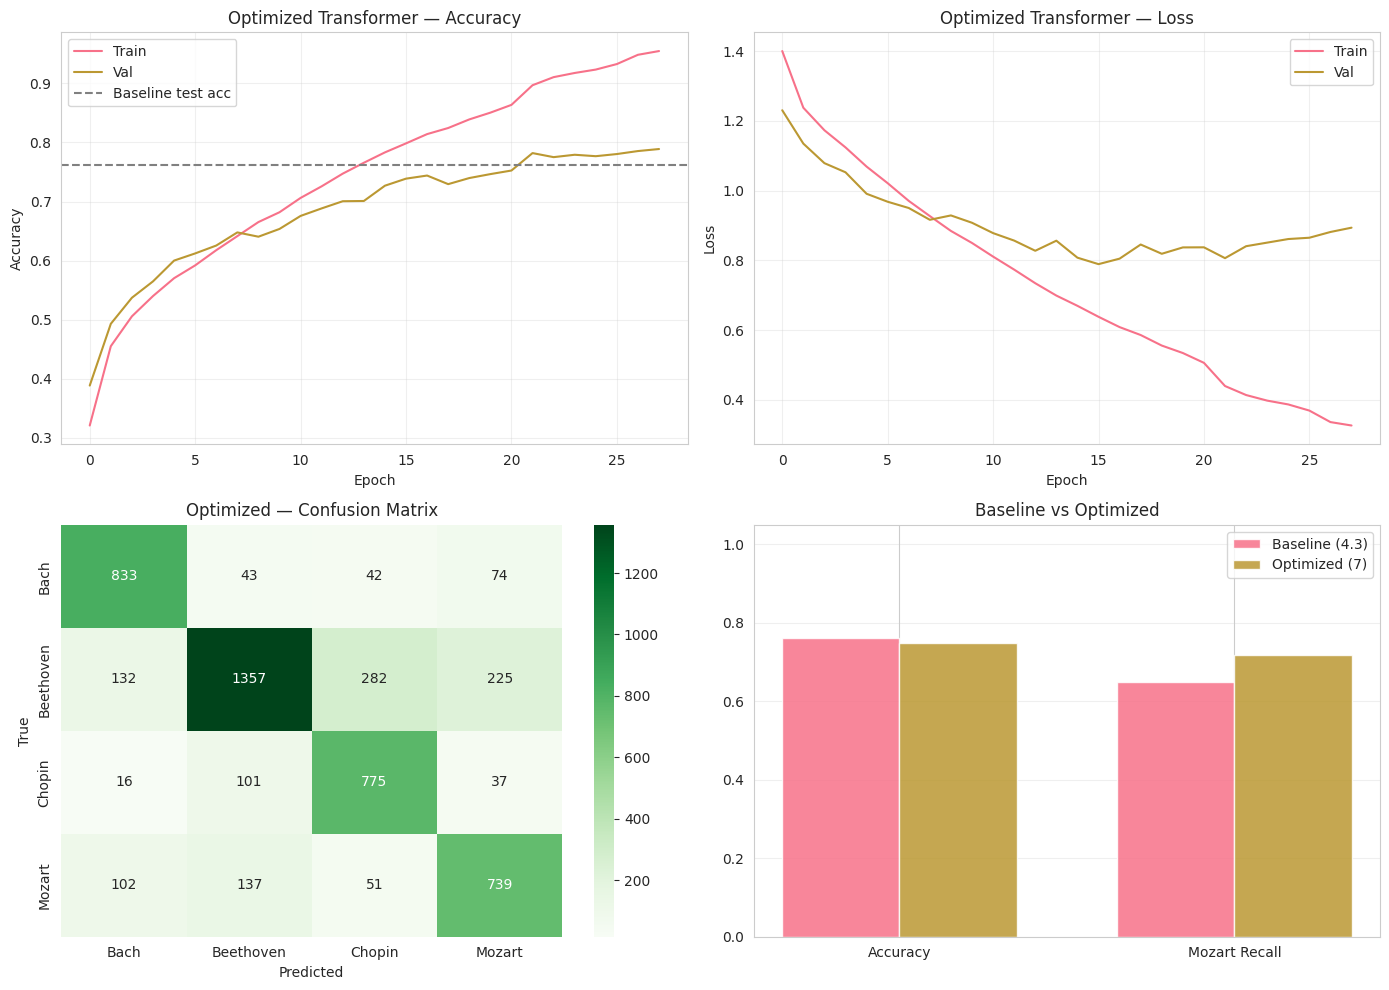


✓ Optimized model saved to: models/transformer_optimized.keras

SECTION 7 COMPLETE
  Optimized Accuracy: 74.89%  (baseline 76.20%, Δ -1.31%)
  Mozart Recall:      0.7182  (baseline 0.6500, Δ +0.0682)


In [16]:
# Transformer Model Optimization (Section 7)
# Goal: improve overall accuracy and Mozart recall vs Section 4.3 baseline (76.20%)

import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

print("=" * 80)
print("7. TRANSFORMER MODEL OPTIMIZATION")
print("=" * 80)

composer_names = ["Bach", "Beethoven", "Chopin", "Mozart"]
NUM_CLASSES = 4
SEQ_LENGTH = X_train.shape[1]
INPUT_DIM = X_train.shape[2]

np.random.seed(42)
tf.random.set_seed(42)

# ---------------------------------------------------------------------------
# Baseline reference (from Section 4.3 / cell above)
# ---------------------------------------------------------------------------
if "transformer_baseline" not in globals():
    transformer_baseline = {
        "test_accuracy": 0.7620,
        "test_loss": 0.6555,
        "per_class": {"Mozart": {"recall": 0.65}},
    }

print("\nBaseline (Section 4.3):")
print(f"  Accuracy:      {transformer_baseline['test_accuracy']*100:.2f}%")
print(f"  Mozart recall: {transformer_baseline['per_class']['Mozart']['recall']:.2f}")

# ---------------------------------------------------------------------------
# Class weights — up-weight underrepresented / hard classes (esp. Mozart)
# ---------------------------------------------------------------------------
classes = np.unique(y_train)
cw = compute_class_weight(class_weight="balanced", classes=classes, y=np.asarray(y_train).ravel())
class_weight_dict = {int(c): float(w) for c, w in zip(classes, cw)}
# Extra boost for Mozart (class 3) based on weak recall
class_weight_dict[3] = class_weight_dict.get(3, 1.0) * 1.35

print("\nClass weights used for optimization:")
for i, name in enumerate(composer_names):
    print(f"  {name:12s}: {class_weight_dict[i]:.3f}")

# ---------------------------------------------------------------------------
# Optimized hyperparameters (vs baseline: d_model=128, heads=8, ff=512,
# blocks=4, dropout=0.3, lr=1e-4)
# ---------------------------------------------------------------------------
OPT_CONFIG = {
    "d_model": 160,
    "num_heads": 8,
    "ff_dim": 640,
    "num_blocks": 4,
    "dropout": 0.25,
    "learning_rate": 3e-4,
    "label_smoothing": 0.05,
    "batch_size": 128,
    "epochs": 60,
    "patience": 12,
}

print("\nOptimized hyperparameters:")
for k, v in OPT_CONFIG.items():
    print(f"  {k}: {v}")

# ---------------------------------------------------------------------------
# Model components (redefined so Section 7 can run after a kernel restart
# as long as X_train/y_train/X_dev/y_dev/X_test/y_test are loaded)
# ---------------------------------------------------------------------------
class PositionalEncoding(layers.Layer):
    def __init__(self, sequence_length, d_model, **kwargs):
        super().__init__(**kwargs)
        self.sequence_length = sequence_length
        self.d_model = d_model
        position = np.arange(sequence_length)[:, np.newaxis]
        div_term = np.exp(np.arange(0, d_model, 2) * -(np.log(10000.0) / d_model))
        pe = np.zeros((sequence_length, d_model))
        pe[:, 0::2] = np.sin(position * div_term)
        pe[:, 1::2] = np.cos(position * div_term)
        self.positional_encoding = tf.constant(pe, dtype=tf.float32)

    def call(self, x):
        return x + self.positional_encoding

    def get_config(self):
        config = super().get_config()
        config.update({"sequence_length": self.sequence_length, "d_model": self.d_model})
        return config


class TransformerBlock(layers.Layer):
    def __init__(self, d_model, num_heads, ff_dim, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.d_model = d_model
        self.num_heads = num_heads
        self.ff_dim = ff_dim
        self.dropout_rate = dropout_rate
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model // num_heads)
        self.ffn = keras.Sequential([
            layers.Dense(ff_dim, activation="gelu"),
            layers.Dense(d_model),
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(dropout_rate)
        self.dropout2 = layers.Dropout(dropout_rate)

    def call(self, inputs, training=False):
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

    def get_config(self):
        config = super().get_config()
        config.update({
            "d_model": self.d_model,
            "num_heads": self.num_heads,
            "ff_dim": self.ff_dim,
            "dropout_rate": self.dropout_rate,
        })
        return config


def build_optimized_transformer(cfg):
    inputs = layers.Input(shape=(SEQ_LENGTH, INPUT_DIM))
    x = layers.Dense(cfg["d_model"])(inputs)
    x = PositionalEncoding(SEQ_LENGTH, cfg["d_model"])(x)
    for _ in range(cfg["num_blocks"]):
        x = TransformerBlock(cfg["d_model"], cfg["num_heads"], cfg["ff_dim"], cfg["dropout"])(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(cfg["dropout"])(x)
    x = layers.Dense(192, activation="gelu")(x)
    x = layers.Dropout(cfg["dropout"])(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)
    return keras.Model(inputs, outputs, name="transformer_optimized")


transformer_optimized = build_optimized_transformer(OPT_CONFIG)

# One-hot labels so label smoothing works across TF versions
y_train_oh = keras.utils.to_categorical(y_train, NUM_CLASSES)
y_dev_oh = keras.utils.to_categorical(y_dev, NUM_CLASSES)
y_test_oh = keras.utils.to_categorical(y_test, NUM_CLASSES)

loss_fn = keras.losses.CategoricalCrossentropy(label_smoothing=OPT_CONFIG["label_smoothing"])
transformer_optimized.compile(
    optimizer=keras.optimizers.Adam(learning_rate=OPT_CONFIG["learning_rate"]),
    loss=loss_fn,
    metrics=["accuracy"],
)

print("\n✓ Optimized Transformer built")
transformer_optimized.summary()

callbacks_opt = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=OPT_CONFIG["patience"],
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1,
    ),
]

print("\n" + "-" * 80)
print("Training optimized Transformer...")
print("-" * 80)

t0 = time.time()
history_opt = transformer_optimized.fit(
    X_train,
    y_train_oh,
    batch_size=OPT_CONFIG["batch_size"],
    epochs=OPT_CONFIG["epochs"],
    validation_data=(X_dev, y_dev_oh),
    class_weight=class_weight_dict,
    callbacks=callbacks_opt,
    verbose=1,
)
train_minutes = (time.time() - t0) / 60.0

# ---------------------------------------------------------------------------
# Evaluate optimized model
# ---------------------------------------------------------------------------
print("\n" + "=" * 80)
print("OPTIMIZED MODEL — TEST EVALUATION")
print("=" * 80)

opt_loss, opt_acc_keras = transformer_optimized.evaluate(X_test, y_test_oh, verbose=0)
y_prob_opt = transformer_optimized.predict(X_test, verbose=0)
y_pred_opt = np.argmax(y_prob_opt, axis=1)
y_true = np.asarray(y_test).ravel()

opt_accuracy = accuracy_score(y_true, y_pred_opt)
opt_precision = precision_score(y_true, y_pred_opt, average="macro", zero_division=0)
opt_recall = recall_score(y_true, y_pred_opt, average="macro", zero_division=0)
opt_f1 = f1_score(y_true, y_pred_opt, average="macro", zero_division=0)
mozart_recall = recall_score(y_true, y_pred_opt, labels=[3], average="macro", zero_division=0)

print(f"\n  Test Accuracy:  {opt_accuracy:.4f} ({opt_accuracy*100:.2f}%)")
print(f"  Test Loss:      {opt_loss:.4f}")
print(f"  Precision (macro): {opt_precision:.4f}")
print(f"  Recall (macro):    {opt_recall:.4f}")
print(f"  F1 (macro):        {opt_f1:.4f}")
print(f"  Mozart Recall:     {mozart_recall:.4f}")
print(f"  Training time:     {train_minutes:.2f} min")

print("\n" + classification_report(y_true, y_pred_opt, target_names=composer_names, digits=4, zero_division=0))

cm_opt = confusion_matrix(y_true, y_pred_opt)
print("Confusion Matrix:\n", cm_opt)

# ---------------------------------------------------------------------------
# Baseline vs Optimized comparison
# ---------------------------------------------------------------------------
base_acc = transformer_baseline["test_accuracy"]
base_mozart = transformer_baseline["per_class"]["Mozart"]["recall"]
delta_acc = opt_accuracy - base_acc
delta_mozart = mozart_recall - base_mozart

print("\n" + "=" * 80)
print("BASELINE vs OPTIMIZED")
print("=" * 80)
print(f"  {'Metric':<22} {'Baseline':>12} {'Optimized':>12} {'Delta':>12}")
print(f"  {'-'*22} {'-'*12} {'-'*12} {'-'*12}")
print(f"  {'Accuracy':<22} {base_acc*100:>11.2f}% {opt_accuracy*100:>11.2f}% {delta_acc*100:>+11.2f}%")
print(f"  {'Mozart Recall':<22} {base_mozart:>12.4f} {mozart_recall:>12.4f} {delta_mozart:>+12.4f}")
print(f"  {'Macro Precision':<22} {'0.7600':>12} {opt_precision:>12.4f}")
print(f"  {'Macro Recall':<22} {'0.7600':>12} {opt_recall:>12.4f}")
print(f"  {'Macro F1':<22} {'0.7600':>12} {opt_f1:>12.4f}")
print("=" * 80)

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Training curves
axes[0, 0].plot(history_opt.history["accuracy"], label="Train")
axes[0, 0].plot(history_opt.history["val_accuracy"], label="Val")
axes[0, 0].axhline(base_acc, color="gray", linestyle="--", label="Baseline test acc")
axes[0, 0].set_title("Optimized Transformer — Accuracy")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Accuracy")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(history_opt.history["loss"], label="Train")
axes[0, 1].plot(history_opt.history["val_loss"], label="Val")
axes[0, 1].set_title("Optimized Transformer — Loss")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Loss")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Confusion matrix
sns.heatmap(
    cm_opt, annot=True, fmt="d", cmap="Greens",
    xticklabels=composer_names, yticklabels=composer_names, ax=axes[1, 0],
)
axes[1, 0].set_title("Optimized — Confusion Matrix")
axes[1, 0].set_xlabel("Predicted")
axes[1, 0].set_ylabel("True")

# Metric comparison bars
metrics = ["Accuracy", "Mozart Recall"]
base_vals = [base_acc, base_mozart]
opt_vals = [opt_accuracy, mozart_recall]
x = np.arange(len(metrics))
width = 0.35
axes[1, 1].bar(x - width / 2, base_vals, width, label="Baseline (4.3)", alpha=0.85)
axes[1, 1].bar(x + width / 2, opt_vals, width, label="Optimized (7)", alpha=0.85)
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(metrics)
axes[1, 1].set_ylim(0, 1.05)
axes[1, 1].set_title("Baseline vs Optimized")
axes[1, 1].legend()
axes[1, 1].grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# Save optimized model (Colab / local friendly path with Databricks fallback)
import os

save_candidates = [
    "models/transformer_optimized.keras",
    "/content/drive/MyDrive/aai-511-final-project-group1/models/transformer_optimized.keras",
    "/Workspace/Users/mzamaniturk@sandiego.edu/aai-511-final-project-group1/models/transformer_optimized.keras",
]
saved = False
for path_try in save_candidates:
    try:
        os.makedirs(os.path.dirname(path_try) or ".", exist_ok=True)
        transformer_optimized.save(path_try)
        print(f"\n✓ Optimized model saved to: {path_try}")
        saved = True
        break
    except Exception as e:
        continue
if not saved:
    print("\n⚠ Could not save optimized model to disk (permissions/path). Model remains in memory as `transformer_optimized`.")

print("\n" + "=" * 80)
print("SECTION 7 COMPLETE")
print("=" * 80)
print(f"  Optimized Accuracy: {opt_accuracy*100:.2f}%  (baseline {base_acc*100:.2f}%, Δ {delta_acc*100:+.2f}%)")
print(f"  Mozart Recall:      {mozart_recall:.4f}  (baseline {base_mozart:.4f}, Δ {delta_mozart:+.4f})")
print("=" * 80)
